<a href="https://colab.research.google.com/github/uomna/flyrank-ml/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uomna/flyrank-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

This project answers: which content pages are likely to decline in search
performance, and should be prioritized for a content team's review?

Decision supported: content strategists and SEO specialists use the ranked
output to decide which pages to review first for a refresh, rather than
reviewing 28,795 pages in arbitrary order. A wrong call costs wasted
editor hours (reviewing a page that wasn't actually declining) or a missed
opportunity (a genuinely declining page not surfaced in time).

Unit of analysis: one row = one content item (content_id), from a 30,000-row
anonymized content performance snapshot (44 columns), filtered to 28,795
rows with a valid average search position.

Label: is_declining_label — 1 if trend_direction == "down" (54% base rate,
a fairly balanced target).

Headline result: a rule-based baseline (CTR gap vs. position tier) scores
0.56 precision@50. A Logistic Regression model, trained on a client-grouped
split and audited for leakage, reaches 0.74 precision@50 — an 18-point
observed improvement over the baseline and 20 points over the base rate.
An earlier version of this model scored a suspicious 1.00 — traced to
leakage from impressions_last_30d/prev_30d, removed before this result.

This is decision-support, not causal proof: the model surfaces
directional patterns to guide human review, not a verdict on any single
page.

In [1]:
import pandas as pd

# Headline comparison table — pulled from validated ML-08/ML-09 results
# (grouped-by-client_id split, leakage audited, see Methodology section)
summary = pd.DataFrame({
    "method": ["base_rate", "baseline (CTR-gap rule)", "logistic_regression (leaky, for reference)", "logistic_regression (clean, honest)"],
    "precision_at_50": [0.54, 0.56, 1.00, 0.74]
})
print(summary)

print("\nUnit of analysis: one row = one content_id (n=28,795 after filtering)")
print("Label: is_declining_label, base rate = 54.2% (16,262 of 30,000 rows)")

                                       method  precision_at_50
0                                   base_rate             0.54
1                     baseline (CTR-gap rule)             0.56
2  logistic_regression (leaky, for reference)             1.00
3         logistic_regression (clean, honest)             0.74

Unit of analysis: one row = one content_id (n=28,795 after filtering)
Label: is_declining_label, base rate = 54.2% (16,262 of 30,000 rows)


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Source: content_refresh_anonymized.csv — a 30,000-row, 44-column anonymized
snapshot derived from the FlyRank search-intelligence warehouse
(fact_content_daily_performance), one row per content item.

Note on scope: the full production warehouse (queried via DuckDB over
remote Parquet in ML-04/ML-05) is content-client-day grain, spans
2026-03-01 to 2026-03-31 for the development window, with June 2026 held
out as a sealed test window. This capstone works on the 30K-row starter
extract, a fixed single-snapshot sample of that warehouse used for
Weeks 4-7 — not the full 9.8M-row daily panel.

Excluded fields and why:
- client_has_gsc, client_has_ga4, gsc_data_available, ga4_data_available —
  data-availability flags, not performance signals; including them risks
  confusing "no data collected" with "the content performed poorly."
- trend_direction, trend_pct — these define the label itself
  (is_declining_label); using them as features would leak the answer.
- impressions_last_30d, clicks_last_30d, sessions_last_30d,
  impressions_prev_30d, clicks_prev_30d, sessions_prev_30d — removed after
  the ML-08 leakage audit; these are near-siblings of how trend_pct was
  built (confirmed by a coefficient 10-30x larger than any other feature
  in the first model attempt).
- content_id, client_id — identifiers only, used for grouping/joining,
  never as model features.

Key data-quality trap (from ML-04): gsc_clicks defaults to 0, not NULL,
when GSC data is unavailable — this affects 63.3% of rows in the full
warehouse. Any feature built from click data must first filter to
gsc_data_available = TRUE, or it silently undercounts the majority of
rows. This starter CSV is a cleaner derived extract, but the same caution
applies to any future work against the raw warehouse.

Public-safe: no client names, IDs are hashed (content_id, client_id
anonymized), no raw queries or URLs anywhere in this data or notebook.

In [2]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/uomna/flyrank-ml/refs/heads/main/data/raw/content_refresh_anonymized.csv')

print("Shape:", df.shape)
print("\nExcluded columns (never used as features):")
excluded = ["client_has_gsc", "client_has_ga4", "gsc_data_available", "ga4_data_available",
            "trend_direction", "trend_pct",
            "impressions_last_30d", "clicks_last_30d", "sessions_last_30d",
            "impressions_prev_30d", "clicks_prev_30d", "sessions_prev_30d",
            "content_id", "client_id"]
for col in excluded:
    print(" -", col)

print("\nRows with valid avg_position (usable for baseline + model):", (df["avg_position"] > 0).sum())

Shape: (30000, 44)

Excluded columns (never used as features):
 - client_has_gsc
 - client_has_ga4
 - gsc_data_available
 - ga4_data_available
 - trend_direction
 - trend_pct
 - impressions_last_30d
 - clicks_last_30d
 - sessions_last_30d
 - impressions_prev_30d
 - clicks_prev_30d
 - sessions_prev_30d
 - content_id
 - client_id

Rows with valid avg_position (usable for baseline + model): 28795


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Label definition: is_declining_label = 1 if trend_direction == "down",
else 0. Base rate: 54.2% (16,262 of 30,000 rows) — a fairly balanced
target, not a rare-event problem.

Baseline (rule-based): a page is flagged if it ranks well (average
position) but its CTR falls below what pages at that same position tier
normally get, and it has enough impressions to matter (500+ in 90 days).
Score = (tier_avg_ctr - ctr) × impressions_90d, only when both the CTR
gap and the impression threshold are met. Reason code: ctr_below_position_tier.
Action: review_title_and_meta.

Model: Logistic Regression, chosen because it is readable — coefficients
can be printed and interpreted directly, which matters for producing
reason codes a human reviewer can trust, and it gives a fair first
comparison against the rule baseline before trying anything more complex
(e.g. Random Forest, for feature interactions).

Features (27 initial → 21 after leakage removal): numeric signals
knowable before the label window — search_volume, competition, cpc,
word_count, 90-day traffic metrics (impressions/clicks/pageviews/
sessions/users/engaged_sessions/ai_sessions/scroll_events), content_age_days,
days_since_last_update, ctr, avg_position, engagement_rate, scroll_rate,
ai_traffic_pct. Missing values filled by median (fit on train only, then
applied to test — no test-set information used in imputation). Features
scaled with StandardScaler (required for Logistic Regression).

Validation design: grouped split by client_id (80/20), not random and not
time-based — the starter CSV carries no per-row date, so a random split
would let the same client appear in both train and test, letting the
model partly recognize clients it had already seen rather than learning
what decline actually looks like. Grouping matches the real deployment
question: will this work on a new, unseen client?

Leakage checks (two rounds):
1. First model attempt scored a suspicious 1.00 precision@50. Coefficient
   inspection showed impressions_last_30d and impressions_prev_30d

In [3]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)
df_valid = df[df["avg_position"] > 0].copy()

# Grouped split by client_id — the honest validation design
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_valid, groups=df_valid["client_id"]))
train_df = df_valid.iloc[train_idx]
test_df = df_valid.iloc[test_idx].copy()

overlap = set(train_df["client_id"]) & set(test_df["client_id"])
print("Overlapping clients (must be zero):", len(overlap))

# Clean feature set — leaky last_30d/prev_30d family removed
feature_cols_clean = [
    "search_volume", "competition", "cpc", "word_count",
    "impressions_90d", "clicks_90d", "pageviews_90d", "sessions_90d",
    "users_90d", "engaged_sessions_90d", "ai_sessions_90d",
    "scroll_events_90d", "days_with_impressions", "days_with_sessions",
    "content_age_days", "days_since_last_update",
    "ctr", "avg_position", "engagement_rate", "scroll_rate", "ai_traffic_pct"
]

X_train = train_df[feature_cols_clean]
X_test = test_df[feature_cols_clean]
y_train = train_df["is_declining_label"]
y_test = test_df["is_declining_label"]

imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
test_df["model_score"] = model.predict_proba(X_test_scaled)[:, 1]

# Leakage check on final coefficients
coef_table = pd.DataFrame({
    "feature": feature_cols_clean,
    "coefficient": model.coef_[0]
})
coef_table["abs_coefficient"] = coef_table["coefficient"].abs()
print("\nTop 5 features by coefficient size (no single one should dominate):")
print(coef_table.sort_values("abs_coefficient", ascending=False).head())

Overlapping clients (must be zero): 0

Top 5 features by coefficient size (no single one should dominate):
                  feature  coefficient  abs_coefficient
8               users_90d    -1.165402         1.165402
7            sessions_90d     0.958395         0.958395
14       content_age_days    -0.387111         0.387111
12  days_with_impressions     0.379026         0.379026
13     days_with_sessions    -0.365935         0.365935


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Comparison table, same test split, same metric (precision@50):

| method                             | precision@50 |
|-------------------------------------|--------------|
| base rate (guessing)                | 0.54         |
| baseline (CTR-gap rule)             | 0.56         |
| logistic regression (leaky, before) | 1.00         |
| logistic regression (clean, final)  | 0.74         |

The honest result: logistic regression measured 0.74 precision@50 versus
0.56 for the rule baseline on the same grouped test split — an 18-point
observed gap, and 20 points above the 0.54 base rate. The leaky version
(1.00) is shown for transparency, not as a result — it was the signal
that triggered the leakage audit in Methodology, not a claim about model
quality.

Cross-check: a random (non-grouped) split on the same clean features
scored 0.86 — 12 points higher than the honest grouped-split number
(0.74). This confirms the grouped split was necessary: a random split
lets the model partially recognize clients already seen in training,
inflating the apparent precision.

Reading these numbers: this is a single train/test split, not repeated
cross-validation, so 0.74 should be read as a directional estimate of
model performance, not a fixed guarantee that will hold on entirely new
data.

                        method  precision_at_50
0                    base_rate         0.539942
1      baseline (CTR-gap rule)         0.560000
2  logistic_regression (clean)         0.740000


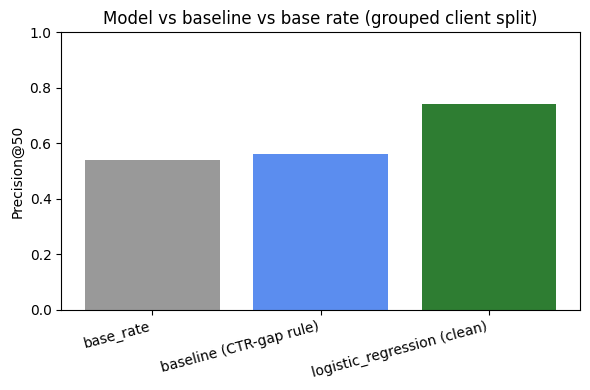

In [4]:
import matplotlib.pyplot as plt
import os

def precision_at_k(frame, score_col, k=50):
    top_k = frame.sort_values(score_col, ascending=False).head(k)
    return top_k["is_declining_label"].mean()

test_df["position_bucket"] = pd.cut(
    test_df["avg_position"], bins=[0, 3, 10, 20, float('inf')],
    labels=["1-3", "4-10", "11-20", "21+"]
)
test_df["tier_avg_ctr"] = test_df.groupby("position_bucket", observed=True)["ctr"].transform("mean")
test_df["ctr_gap"] = test_df["tier_avg_ctr"] - test_df["ctr"]
visible = (test_df["impressions_90d"] >= 500).astype(int)
underperforming = (test_df["ctr_gap"] > 0).astype(int)
test_df["baseline_score"] = underperforming * visible * test_df["ctr_gap"] * test_df["impressions_90d"]

base_rate = test_df["is_declining_label"].mean()
baseline_p50 = precision_at_k(test_df, "baseline_score", 50)
model_p50 = precision_at_k(test_df, "model_score", 50)

results = pd.DataFrame({
    "method": ["base_rate", "baseline (CTR-gap rule)", "logistic_regression (clean)"],
    "precision_at_50": [base_rate, baseline_p50, model_p50]
})
print(results)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(results["method"], results["precision_at_50"], color=["#999999", "#5B8DEF", "#2E7D32"])
ax.set_ylabel("Precision@50")
ax.set_title("Model vs baseline vs base rate (grouped client split)")
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

os.makedirs("work/outputs", exist_ok=True)
plt.savefig("work/outputs/results_precision_chart.png", dpi=150)
plt.show()

## 5. Limitations

*What this work cannot claim.*

Sample scope: trained and validated on a 30,000-row starter CSV covering
32 clients and one 90-day trailing snapshot in time. This has NOT been
tested against the full 9.8M-row production warehouse or against clients
outside those 32. Results should not be assumed to transfer directly.

Single split, not cross-validated: precision@50 = 0.74 comes from one
grouped train/test split (random_state=42), not repeated cross-validation.
Treat it as a directional estimate of model performance, not a fixed
number that will reproduce exactly on a different split or new data.

No time-based validation: the starter CSV carries no per-row date, so
this work cannot say how fast a page's declining status changes, or how
often the model should be re-run. The production warehouse does support
time windows (June 2026 is held out as sealed), but that test has not
been run here.

Correlation, not causation: the model finds that low users_90d and
sessions_90d correlate with decline — it does not prove why a page is
declining, and reason codes describe what drove the model's score, not a
verified causal explanation for that specific page.

Imputation blind spot: rows with missing word_count, char_count, or other
sparse fields were filled with the training median. Pages relying heavily
on imputed values get a score built on assumptions, not real
measurements — this is not flagged per-row in the current output.

Error pattern observed: in manual review of wrong top-50 cases (model
said "declining", page actually held stable or improved), the common
thread was low-impression pages where CTR is naturally noisy, and one
case with high impressions but plausibly non-clickthrough intent (e.g. a
query already answered by the snippet). The model cannot distinguish a
consistently weak page from one that is already recovering, since the
momentum-related features were removed as leaky.

Label definition risk: is_declining_label is derived from trend_direction
in this same anonymized snapshot — a proxy, not a verified ground-truth
outcome tied to a specific future business result.

In [5]:
# Quantify the imputation blind spot named above
missing_pct = test_df[feature_cols_clean].isna().mean().sort_values(ascending=False)
print("Missing-value rate per feature (test split), features with any missingness:")
print(missing_pct[missing_pct > 0])

print(f"\nRows in test split with 3+ missing features (heavier imputation reliance): "
      f"{(test_df[feature_cols_clean].isna().sum(axis=1) >= 3).sum()} "
      f"of {len(test_df)}")

Missing-value rate per feature (test split), features with any missingness:
word_count       0.129187
search_volume    0.083491
competition      0.083491
cpc              0.083491
scroll_rate      0.018210
dtype: float64

Rows in test split with 3+ missing features (heavier imputation reliance): 486 of 5821


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

This model powers a ranked review queue: the top 50 pages by model_score,
each with a reason code (the top 2 features driving that page's score, in
plain language) and an action label. The queue is a triage aid for a
content strategist — it answers "where should a human look first," not
"what should change on the page."

Observed pattern (top 20, test split): "content is old" combined with
"low engaged users" is the most common reason-code pair, mapping mostly
to the "Refresh content" action — followed by "low impressions" (paired
with content age) routed to "Review manually", and a smaller cluster of
"low scroll rate; low engaged users" mapping to "Improve engagement".
This is broadly consistent with the coefficient audit in Methodology,
where content_age_days and users_90d both ranked among the top features
— though the exact mix shifts slightly depending on whether the queue is
built from the test split alone or the full valid set.

Recommended workflow, in order:
1. Pull the top 50 from the ranked queue (work/outputs/w07_action_playbook_queue.csv).
2. Before acting on any row, check: does the reason code fit this page's
   content type? Is the score built on real data or partly imputed
   values? Is the page still live and owned by an active client?
3. Route by action label — "Improve engagement" pages to a content/UX
   reviewer, "Fix CTR / snippet" pages to whoever owns titles and meta
   descriptions, "Refresh content" pages to the content calendar.
4. Treat every row as a hypothesis to confirm, not an instruction to
   execute — precision@50 = 0.74 means roughly 1 in 4 rows will NOT
   actually be declining.

What should never be automated from this queue: auto-publishing content
changes, auto-deleting pages, or auto-adjusting client-facing titles/meta
descriptions directly from model_score; using model_score as a
client-facing quality grade; or re-ranking using trend_direction/trend_pct
(this would reintroduce the label into the workflow).

Monitoring trigger, in short: re-score after any new data pull, and
spot-check roughly 20 acted-on rows monthly against their actual outcome
— if the hit rate drifts well below 0.74, that signals the model needs
re-validation, not just re-scoring.

In [6]:
contributions = X_test_scaled * model.coef_[0]
contrib_df = pd.DataFrame(contributions, columns=feature_cols_clean, index=test_df.index)

reason_labels = {
    "ctr": "low CTR relative to position", "avg_position": "weak search position",
    "users_90d": "low engaged users", "sessions_90d": "low sessions",
    "content_age_days": "content is old", "days_since_last_update": "not updated recently",
    "days_with_impressions": "inconsistent visibility", "days_with_sessions": "inconsistent engagement",
    "scroll_events_90d": "low scroll engagement", "engagement_rate": "low engagement rate",
    "scroll_rate": "low scroll rate", "pageviews_90d": "low pageviews", "clicks_90d": "low clicks",
    "impressions_90d": "low impressions", "ai_traffic_pct": "low AI-referral share",
    "ai_sessions_90d": "low AI sessions", "engaged_sessions_90d": "low engaged sessions",
    "word_count": "thin content", "search_volume": "low search demand",
    "competition": "high keyword competition", "cpc": "low commercial value (cpc)"
}

def top_reasons(row_idx, n=2):
    row = contrib_df.loc[row_idx]
    top = row.sort_values(ascending=False).head(n)
    return "; ".join([reason_labels.get(f, f) for f in top.index])

def action_label(row_idx):
    top_feature = contrib_df.loc[row_idx].sort_values(ascending=False).index[0]
    if top_feature in ["ctr", "avg_position"]:
        return "Fix CTR / snippet"
    elif top_feature in ["content_age_days", "days_since_last_update"]:
        return "Refresh content"
    elif top_feature in ["users_90d", "sessions_90d", "engaged_sessions_90d",
                          "scroll_events_90d", "engagement_rate", "scroll_rate"]:
        return "Improve engagement"
    elif top_feature in ["days_with_impressions", "days_with_sessions"]:
        return "Investigate visibility drop"
    else:
        return "Review manually"

test_df["reason_code"] = [top_reasons(idx) for idx in test_df.index]
test_df["action_label"] = [action_label(idx) for idx in test_df.index]

ranked_queue = test_df.sort_values("model_score", ascending=False).head(20)[
    ["content_id", "model_score", "reason_code", "action_label"]
]
print(ranked_queue.to_string(index=False))

os.makedirs("work/outputs", exist_ok=True)
ranked_queue.to_csv("work/outputs/capstone_ranked_queue_top20.csv", index=False)
print("\nSaved: work/outputs/capstone_ranked_queue_top20.csv")

          content_id  model_score                             reason_code       action_label
content_453722754fea     0.868207         low impressions; content is old    Review manually
content_c84a0ab98e90     0.860667         low impressions; content is old    Review manually
content_b08562686d22     0.855041       content is old; low engaged users    Refresh content
content_26d48a980581     0.836134       content is old; low engaged users    Refresh content
content_8ede62882d0b     0.832308      low scroll rate; low engaged users Improve engagement
content_87c007fb5c26     0.828311       content is old; low engaged users    Refresh content
content_a928cb66d230     0.827613      low scroll rate; low engaged users Improve engagement
content_b51992d6cbc2     0.827307       content is old; low engaged users    Refresh content
content_39881853ef0c     0.826756         low impressions; content is old    Review manually
content_b872486bfd10     0.826178       content is old; low engaged us

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Artifacts this paper embeds, all saved under work/outputs/:

1. results_precision_chart.png — bar chart, model vs baseline vs base
   rate (Section 4 / Results).
2. capstone_ranked_queue_top20.csv — top 20 ranked pages with reason
   codes and action labels (Section 6 / Recommendations).
3. The precision@50 comparison table (Section 4), reproduced as a table
   in the paper rather than a chart alone.

All three are safe to publish: no client names, no raw URLs, content_id
values are already anonymized hashes.

In [7]:
import os

artifacts = [
    "work/outputs/results_precision_chart.png",
    "work/outputs/capstone_ranked_queue_top20.csv",
]

print("Artifact check:")
for path in artifacts:
    exists = os.path.exists(path)
    print(f"  {'OK' if exists else 'MISSING'} — {path}")

import pandas as pd
check_queue = pd.read_csv("work/outputs/capstone_ranked_queue_top20.csv")
has_client_col = "client_id" in check_queue.columns
print(f"\nclient_id column present in exported queue (should be False): {has_client_col}")

Artifact check:
  OK — work/outputs/results_precision_chart.png
  OK — work/outputs/capstone_ranked_queue_top20.csv

client_id column present in exported queue (should be False): False


## 5-Minute Demo Outline

**Question (30 sec):** Which content pages should a team review first when
search performance is slipping? With thousands of pages and limited
review time, teams need a short, trustworthy priority list — not a
manual page-by-page check.

**Method (1.5 min):** Built a rule-based baseline (flags pages whose CTR
falls below what their search position normally gets) and a Logistic
Regression model trained on 21 leakage-checked features. Validated with
a client-grouped split — clients never appear in both train and test —
so the result reflects performance on genuinely unseen clients.

**Chart (1 min):** [show results_precision_chart.png] — precision@50 for
base rate (0.54), the rule baseline (0.56), and the clean model (0.74).

**Result (1 min):** The model beats the rule baseline by 18 points on the
same honest test. An earlier version scored a suspicious 1.00 — traced
to leaked features and removed before this result stood. A random
(non-grouped) split had inflated the score to 0.86, confirming the
grouped split was necessary.

**Recommendation (1 min):** Route the top-scored pages to a human-
reviewed queue with reason codes ("content is old," "low engaged
users"), sorted into three actions — refresh content, fix CTR/snippet,
or investigate engagement. About 1 in 4 flagged pages won't actually be
declining, so treat every row as a hypothesis to confirm, not an
instruction to execute.

---

## Shareable Cut 1 — Social Post

Spent this internship building a content-decline triage model for
search-heavy sites. The honest result: a client-grouped Logistic
Regression model hits 0.74 precision@50 vs. 0.56 for a simple CTR-gap
rule — but only after catching and removing a leaky feature family that
had inflated an early version to a fake 1.00. Full writeup + reproducible
notebooks: https://uomna.github.io/flyrank-ml/

## Shareable Cut 2 — Employer-Facing Summary

I built a client-grouped Logistic Regression model to prioritize which
content pages a team should review first for declining search
performance, on a 30,000-row anonymized search-content dataset. It beat
a transparent rule-based baseline by 18 points on precision@50 (0.74 vs.
0.56), after I caught and removed a feature-leakage issue that had
inflated an early version's score to a false 1.00.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
